In [24]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from model_ranking import (
    find_batchnorm_pred_path,
    get_NA_prediction_path,
    load_h5

)
from pytorch3dunet.unet3d.config import load_config_direct #pyright: ignore[reportUnknownVariableType]

In [16]:
models = {
    "RtoE": [
        "RmtoE_model_Res1",
    ],
}
model_name = "RmtoE_model_Res1"
adabn_base_path = Path("/g/kreshuk/talks/model_ranking_results/AdaptiveBatchNorm/Mitochondria/train_mode_stats")

In [17]:
pred_path = find_batchnorm_pred_path(
    model_name, 
    adabn_base_path, 
    perturbation="none"
)

In [31]:
adabn_preds = load_h5(pred_path, "predictions")
adabn_patch_pos = load_h5(pred_path, "patch_index")
adabn_f1_scores = load_h5(pred_path, "F1_eval")[:,1]

In [32]:
print(adabn_f1_scores.shape)

(750,)


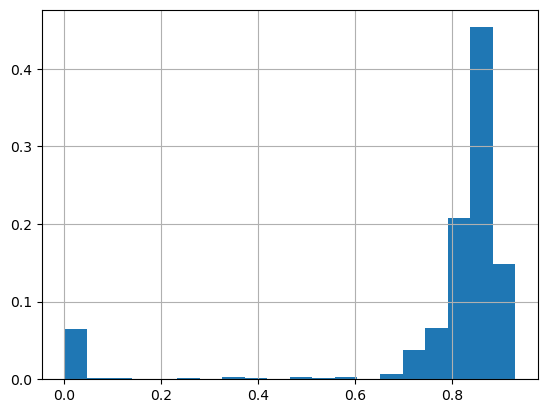

In [34]:
_ = plt.hist(adabn_f1_scores, bins=20, weights=np.ones(len(adabn_f1_scores)) / len(adabn_f1_scores))
plt.grid()
plt.show()

In [35]:
base_transfer_path = Path("/scratch/talks/consistency_results/patch_segmentation/mitochondria")
target = "EPFL"
run_approach= "consistency"
run_id = "P_full"

In [36]:
yaml_paths = list((pred_path.parent.parent.parent.parent / "checkpoints").glob("*.yaml"))
assert len(yaml_paths) == 1, f"Expected one YAML file for {model_name}, found {len(yaml_paths)}"
yaml_path = yaml_paths[0]
initial_model_name = Path(load_config_direct(yaml_path)[0]["model_cfg"]["source_checkpoint"]).parent.stem
initial_pred_path = get_NA_prediction_path(
    model_name=initial_model_name,
    target=target,
    base_path=base_transfer_path,
    approach=run_approach,
    run_id=run_id,
)

In [37]:
preds = load_h5(initial_pred_path, "predictions")
patch_pos = load_h5(initial_pred_path, "patch_index")
f1_scores = load_h5(initial_pred_path, "hard_f1")[:,1]

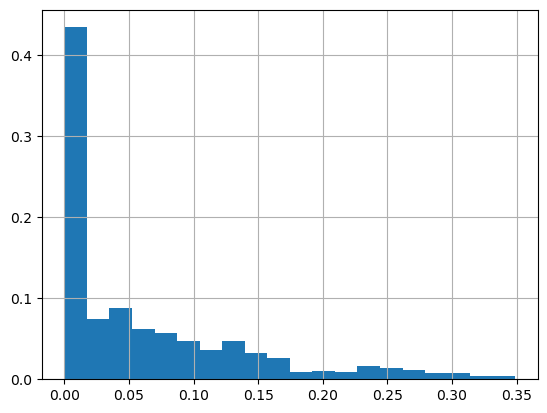

In [38]:
_ = plt.hist(f1_scores, bins=20, weights=np.ones(len(f1_scores)) / len(f1_scores))
plt.grid()
plt.show()

# Show prediction patches

In [44]:
E_path = "/scratch/talks/data/EPFL/test.h5"
E_data = load_h5(E_path, "labels")

In [45]:
ids_f108 = np.where(adabn_f1_scores>0.8)[0]

In [49]:
rng = np.random.default_rng(42)
selected_ids = rng.choice(ids_f108, size=5, replace=False)

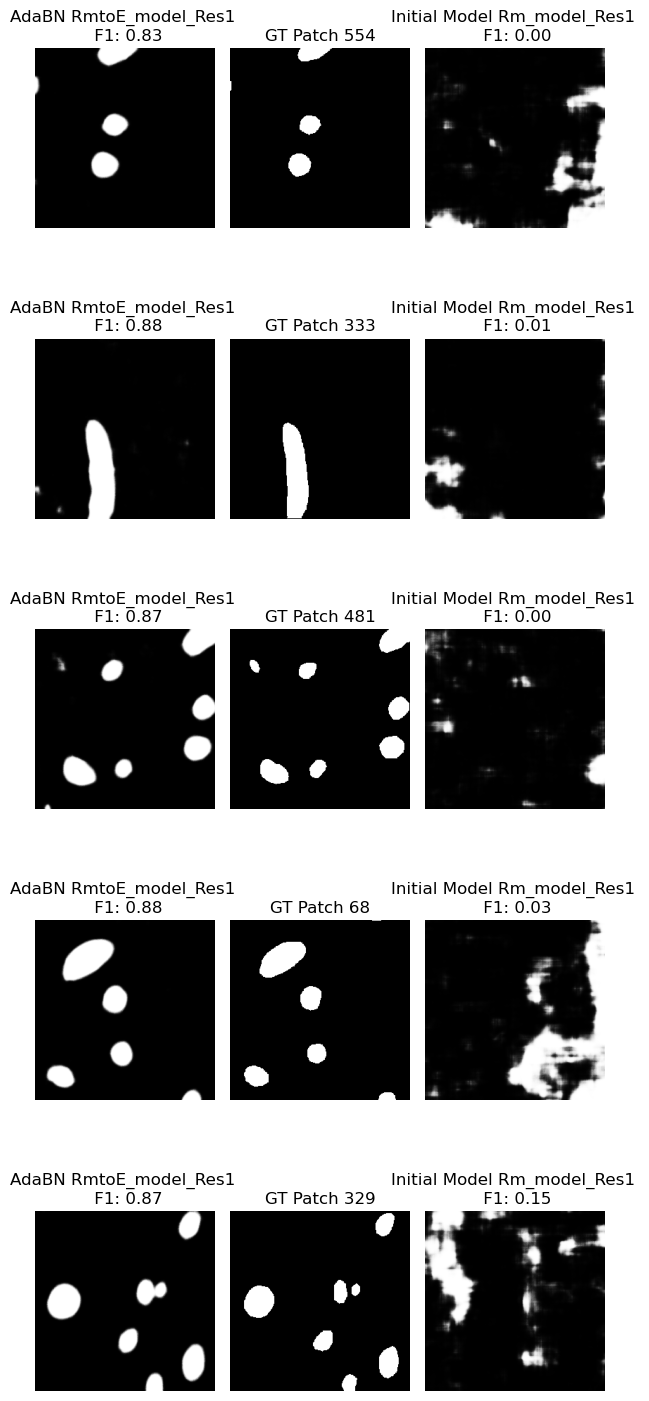

In [50]:

fig, axes = plt.subplots(len(selected_ids), 3, figsize=(6, 3 * len(selected_ids)))

for i, idx in enumerate(selected_ids):
    # Get patch coordinates
    z, y, x = patch_pos[idx]
    # Extract prediction and ground truth patch
    adabn_pred_patch = adabn_preds[idx, 0, 0]
    gt_patch = E_data[z[0]:z[1], y[0]:y[1], x[0]:x[1]]

    # Plot prediction
    axes[i, 0].imshow(adabn_pred_patch.squeeze(), cmap='gray')
    axes[i, 0].set_title(f'AdaBN {model_name} \n F1: {adabn_f1_scores[idx]:.2f}')
    axes[i, 0].axis('off')

    # Plot ground truth
    axes[i, 1].imshow(gt_patch.squeeze(), cmap='gray')
    axes[i, 1].set_title(f'GT Patch {idx}')
    axes[i, 1].axis('off')

    # Plot initial model prediction
    initial_pred_patch = preds[idx, 0, 0]
    axes[i, 2].imshow(initial_pred_patch.squeeze(), cmap='gray')
    axes[i, 2].set_title(f'Initial Model {initial_model_name} \n F1: {f1_scores[idx]:.2f}')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()